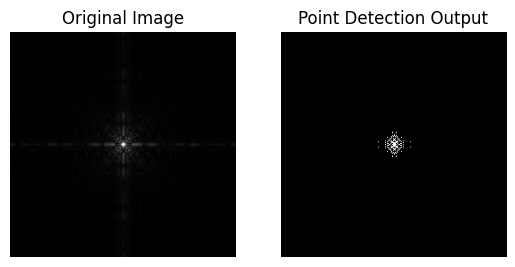

In [ ]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Point Detection

original_image=cv2.imread("/content/Point_Detection.bmp",1)
original=cv2.imread("/content/Point_Detection.bmp",0)

padded=np.pad(original,((1,1),(1,1)),mode='constant').astype(float)
output=np.zeros_like(original,dtype='float')

rows,cols=original.shape

mask=[[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]

T=125

for i in range(rows):
  for j in range(cols):
    s=0
    for k in range(3):
      for l in range(3):
        s=s+padded[i+k][j+l]*mask[k][l]

    if(abs(s)>T):
      output[i][j]=255
    else:
      output[i][j]=0

plt.subplot(1,2,1)
plt.imshow(original_image,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output,cmap='gray')
plt.title("Point Detection Output")
plt.axis("off")

plt.show()


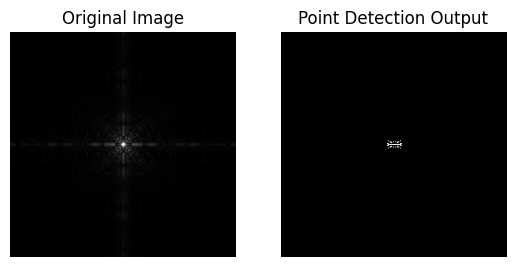

In [ ]:
# Line Detection

original_image=cv2.imread("/content/Point_Detection.bmp",1)
original=cv2.imread("/content/Point_Detection.bmp",0)

padded=np.pad(original,((1,1),(1,1)),mode='constant').astype(float)
output=np.zeros_like(original,dtype='float')

rows,cols=original.shape

mask=[[-1,-1,-1],[2,2,2],[-1,-1,-1]]

T=125

for i in range(rows):
  for j in range(cols):
    s=0
    for k in range(3):
      for l in range(3):
        s=s+padded[i+k][j+l]*mask[k][l]

    if(abs(s)>T):
      output[i][j]=255
    else:
      output[i][j]=0

plt.subplot(1,2,1)
plt.imshow(original_image,cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output,cmap='gray')
plt.title("Point Detection Output")
plt.axis("off")

plt.show()


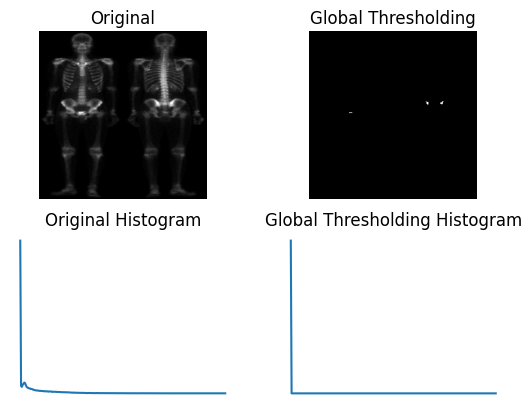

In [ ]:
#  Global Thresholding

original_image=cv2.imread("/content/int_slicing2.bmp",1)
original=cv2.imread("/content/int_slicing2.bmp",0)

original_hist=cv2.calcHist([original],[0],None,[256],[0,256])

T=238

rows, cols = original.shape

output = np.zeros_like(original)
output_hist=cv2.calcHist([output],[0],None,[256],[0,256])

for i in range(rows):
    for j in range(cols):
        if original[i][j] > T:
            output[i][j] = 255
        else:
            output[i][j] = 0

plt.subplot(2,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(output, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2,2,3)
plt.plot(original_hist)
plt.title("Original Histogram")
plt.axis("off")

plt.subplot(2,2,4)
plt.plot(output_hist)
plt.title("Global Thresholding Histogram")
plt.axis("off")

plt.show()

[np.float64(27.49754376372671), np.float64(33.49859025267727), np.float64(37.06631799600353), np.float64(39.49003071353455)]


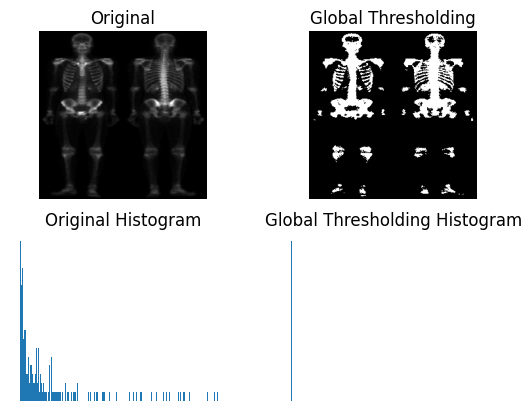

In [ ]:
# Iterative Global Thresholding

original_image=cv2.imread("/content/int_slicing2.bmp",1)
original=cv2.imread("/content/int_slicing2.bmp",0)

original_hist=cv2.calcHist([original],[0],None,[256],[0,256])

T=0
Tnew=np.mean(original)
delta=3

T_values=[]

output=np.zeros_like(original)
rows,cols=original.shape

while abs(T-Tnew)>delta:

  T=Tnew

  G1 = []
  G2 = []

  for i in range(rows):
      for j in range(cols):
          if original[i][j] >= T:
              G1.append(original[i][j])   # bright pixels
          else:
              G2.append(original[i][j])   # dark pixels

  #Average brightness of: bright region,dark region

  m1=np.mean(G1)
  m2=np.mean(G2)

  Tnew = (m1 + m2) / 2

  T_values.append(Tnew)

# Apply threshold: pixels > Tnew → white (255), others → black (0)
for i in range(rows):
    for j in range(cols):
        if original[i][j] > Tnew:
            output[i][j] = 255
        else:
            output[i][j] = 0

output_hist=cv2.calcHist([output],[0],None,[256],[0,256])

print(T_values)

plt.subplot(2,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(output, cmap='gray')
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2,2,3)
plt.hist(original_hist,bins=256,range=(0,256))
plt.title("Original Histogram")
plt.axis("off")

plt.subplot(2,2,4)
plt.hist(output_hist,bins=256,range=(0,256))
plt.title("Global Thresholding Histogram")
plt.axis("off")

plt.show()